# Rootzone Model v1f — EC from v1c + pH Time-of-Day + Cleaner Fert Features

v1c EC model preserved exactly (best EC MAE=0.1906).

pH improvements cherry-picked from v1e:
- Time-of-day circular features added to pH: hour_sin_a/b, hour_cos_a/b (diurnal pH cycle)
- total_fert replaces fert_acid for pH features (acid fert is only 0.3% non-zero, split was adding noise)

EC model still uses fert_acid/fert_salt split (meaningful for ionic strength).


In [15]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()
print('Loaded:', len(df), 'rows')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4','Potassium Chloride[mg] - KCL',
    'Kortin [mg]','Ammonium Nitrate [mg] -NH4NO3','Gypsum - CaSO4*2H2O [mg]']

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)
def _sum_avail(fr, cols):
    u=[c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric,errors='coerce').fillna(0).sum().sum()) if u else 0.0
def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a='fertilization_type_a_flag' in fr.columns
    b='fertilization_type_b_flag' in fr.columns
    if a or b:
        fa=_to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0.,index=fr.index)
        fb=_to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0.,index=fr.index)
        return ((fa>0)|(fb>0)).astype(float)
    return pd.Series(0.,index=fr.index)

Loaded: 16682 rows


In [ ]:
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)

    # Current state (known at inference time)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])

    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 1e-3)

    # ------------------------------------------------------------------
    # IMPORTANT: drivers are computed ONLY on [t0, t1)
    # This prevents "peeking" at events logged exactly at t1 (same time as the sample).
    # ------------------------------------------------------------------
    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    # Fertigation / irrigation totals in the future window
    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total

    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0

    # Simple "concentration proxy" and a drive feature (still only uses [t0,t1))
    fert_conc = float(fert_total / (irr_total + 1.0))
    salt_balance = float(fert_salt_total - irr_total)  # net salt-vs-dilution proxy

    # Climate aggregates in the future window
    # VPD mean
    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        ts = _to_num(seg['internal_air_temp_c'])
        rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)

    canopy_mean = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy_mean)
    evapo_concentration = float(ET0_sum * canopy_mean)

    # Temperature dynamics over the window
    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend = 0.0
        temp_range = 0.0

    # Radiation daylight proportion
    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    if len(rad_s) > 0:
        daylight_rows = int((rad_s > 10).sum())
        daylight_hours = daylight_rows / 6.0  # 10-minute intervals
    else:
        daylight_hours = 0.0
    daylight_proportion = float(daylight_hours / safe_gap_h)

    # Hours since last irr/fert within [t0,t1)
    if 'irrigation_ml_current' in seg.columns and len(seg) > 0:
        ie = _to_num(seg['irrigation_ml_current'])
        ii = ie[ie > 0].index
        hrs_since_irr = float((t1 - ii.max()).total_seconds() / 3600.0) if len(ii) > 0 else gap_h
    else:
        hrs_since_irr = gap_h

    fflag = _get_fert_any(seg) if len(seg) > 0 else pd.Series(0., index=seg.index)
    fi2 = fflag[fflag > 0].index if len(seg) > 0 else []
    hrs_since_fert = float((t1 - fi2.max()).total_seconds() / 3600.0) if len(fi2) > 0 else gap_h

    # Fert events count within [t0,t1)
    if len(fflag) > 0:
        n_fert_events = int(fflag.diff().clip(lower=0).sum())
        n_fert_events = max(n_fert_events, int(fflag.iloc[0] > 0))
    else:
        n_fert_events = 0

    fert_per_event = float(fert_total / (n_fert_events + 1e-3)) if fert_total > 0 else 0.0

    # Agronomic ratio
    leaching_fraction = float(irr_total / (ET0_sum + 1e-3))

    # "Drive" terms (kept for continuity)
    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    ph_drive = float(fert_total / (ph0 + 1e-3))

    # Time-of-day features (t0 and t1 are known at inference time)
    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0
    hour_sin_a = float(np.sin(2 * np.pi * hour_a / 24))
    hour_cos_a = float(np.cos(2 * np.pi * hour_a / 24))
    hour_sin_b = float(np.sin(2 * np.pi * hour_b / 24))
    hour_cos_b = float(np.cos(2 * np.pi * hour_b / 24))

    dap = float(master_df.loc[t1, 'days_after_planting']) if 'days_after_planting' in master_df.columns else 0.0

    return {
        # state at t0
        'ph0': ph0,
        'ec0': ec0,

        # timing
        'gap_hours': gap_h,

        # totals / core drivers (ONLY [t0,t1))
        'irr_total_t0_t1': irr_total,
        'fert_total_t0_t1': fert_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'salt_balance_t0_t1': salt_balance,

        # climate / uptake drivers (ONLY [t0,t1))
        'ET0_sum_t0_t1': ET0_sum,
        'ET0_per_hour': ET0_per_hour,
        'soil_temp_mean': soil_temp_mean,
        'vpd_mean': vpd_mean,
        'canopy': canopy_mean,
        'transpiration_pull': transpiration_pull,
        'evapo_concentration': evapo_concentration,

        # ratios / derived drivers
        'fert_conc': fert_conc,
        'log_ec_drive': log_ec_drive,
        'ph_drive': ph_drive,
        'leaching_fraction': leaching_fraction,
        'fert_per_event': fert_per_event,

        # recency (within window)
        'hrs_since_irr': hrs_since_irr,
        'hrs_since_fert': hrs_since_fert,

        # radiation / daylight
        'rad_max': rad_max,
        'daylight_proportion': daylight_proportion,

        # temp dynamics
        'temp_trend': temp_trend,
        'temp_range': temp_range,

        # growth stage
        'days_after_planting': dap,

        # diurnal
        'hour_sin_a': hour_sin_a, 'hour_cos_a': hour_cos_a,
        'hour_sin_b': hour_sin_b, 'hour_cos_b': hour_cos_b,
    }


In [18]:
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
diag=[]
for j in range(1,len(sensor_idx)):
    f=get_features_for_row(master_df,sensor_idx[j-1],sensor_idx[j])
    f['ph_true']=float(master_df.loc[sensor_idx[j],'ph'])
    f['ec_true']=float(master_df.loc[sensor_idx[j],'ec_ms'])
    diag.append((sensor_idx[j],f))
ds=pd.DataFrame([r[1] for r in diag],index=[r[0] for r in diag]).sort_index()
print(f'Diagnostic rows: {len(ds)}')

feature_cols_ph=[
    'ph0','ec0',
    'fert_total_t0_t1','irr_total_t0_t1',
    'ET0_sum_t0_t1','ET0_per_hour',
    'soil_temp_mean','daylight_proportion',
    'leaching_fraction',
    'hrs_since_irr','hrs_since_fert',
    'temp_trend','temp_range','rad_max',
    'canopy','transpiration_pull',
    'ph_drive',
    'hour_sin_b','hour_cos_b',
]

feature_cols_ec=[
    'ec0','ph0',
    'irr_total_t0_t1',
    'salt_balance_t0_t1',
    'ET0_sum_t0_t1','evapo_concentration',
    'leaching_fraction',
    'hrs_since_irr','hrs_since_fert',
    'transpiration_pull',
    'fert_conc','log_ec_drive',
    'temp_trend',
    'gap_hours',
]

for n,c in [('pH',feature_cols_ph),('EC',feature_cols_ec)]:
    m=[x for x in c if x not in ds.columns]
    print(f'{n}: {len(c)} feats'+(' MISSING:'+str(m) if m else ' OK'))

Diagnostic rows: 108
pH: 19 feats OK
EC: 14 feats OK


In [ ]:
warmup=50; _eps=1e-6
train_rows=[]
for j in range(1,warmup+1):
    f=get_features_for_row(master_df,sensor_idx[j-1],sensor_idx[j])
    f['ph_true']=float(master_df.loc[sensor_idx[j],'ph'])
    f['ec_true']=float(master_df.loc[sensor_idx[j],'ec_ms'])
    f['timestamp']=sensor_idx[j]
    train_rows.append(f)
train_df=pd.DataFrame(train_rows).set_index('timestamp').sort_index()
print(f'Warm-up: {len(train_df)} rows')

def fit_models(tdf):
    y_ph = (tdf['ph_true'] - tdf['ph0']).astype(float)
    y_ec = (tdf['ec_true'] - tdf['ec0']).astype(float)
    
    pm=xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=3,  
        min_child_weight=7, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
    )
    
    em=xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2,  
        min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.3, reg_lambda=1.5, random_state=42, n_jobs=-1, objective='reg:pseudohubererror', huber_slope=0.1
    )
    
    pm.fit(tdf[feature_cols_ph],y_ph,verbose=False)
    em.fit(tdf[feature_cols_ec],y_ec,verbose=False)
    return pm,em

ph_model,ec_model=fit_models(train_df)
anchor_idx=sensor_idx[warmup]; results=[]; retrain_count=0

for cur in master_df.loc[anchor_idx:].index:
    feats=get_features_for_row(master_df,anchor_idx,cur)
    lp=float(ph_model.predict(pd.DataFrame([feats])[feature_cols_ph])[0])
    le=float(ec_model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])
    pp = float(feats['ph0'] + lp)
    ep = max(0.0, float(feats['ec0'] + le))
    
    row={'timestamp':cur,'gap_hours':feats['gap_hours'],'ph0':feats['ph0'],'ec0':feats['ec0'],
        'ph_pred':pp,'ec_pred':ep,'has_actual':False,
        'ph_true':np.nan,'ec_true':np.nan,'ph_naive':np.nan,'ec_naive':np.nan,
        'ph_abs_error':np.nan,'ec_abs_error':np.nan,
        'ph_abs_error_naive':np.nan,'ec_abs_error_naive':np.nan}
        
    has=pd.notna(master_df.loc[cur,'ph']) and pd.notna(master_df.loc[cur,'ec_ms'])
    if has:
        pt=float(master_df.loc[cur,'ph']); et=float(master_df.loc[cur,'ec_ms'])
        row.update({'has_actual':True,'ph_true':pt,'ec_true':et,
            'ph_naive':feats['ph0'],'ec_naive':feats['ec0'],
            'ph_abs_error':abs(pp-pt),'ec_abs_error':abs(ep-et),
            'ph_abs_error_naive':abs(feats['ph0']-pt),'ec_abs_error_naive':abs(feats['ec0']-et)})
        if cur!=anchor_idx:
            nr={**feats,'ph_true':pt,'ec_true':et,'timestamp':cur}
            train_df=pd.concat([train_df,pd.DataFrame([nr]).set_index('timestamp')]).sort_index()
            ph_model,ec_model=fit_models(train_df)
            retrain_count+=1; anchor_idx=cur
    results.append(row)

res_df=pd.DataFrame(results).set_index('timestamp')
ev=res_df[res_df['has_actual']].copy()
def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))

print(f'\nRetrains: {retrain_count}')
print('='*70)
print('Walk-Forward Metrics')
print('='*70)
print(f'pH MAE:  {mean_absolute_error(ev["ph_true"],ev["ph_pred"]):>8.4f}')
print(f'pH RMSE: {rmse(ev["ph_true"],ev["ph_pred"]):>8.4f}')
print(f'pH Naive:{mean_absolute_error(ev["ph_true"],ev["ph_naive"]):>8.4f}')
print()
print(f'EC MAE:  {mean_absolute_error(ev["ec_true"],ev["ec_pred"]):>8.4f}')
print(f'EC RMSE: {rmse(ev["ec_true"],ev["ec_pred"]):>8.4f}')
print(f'EC Naive:{mean_absolute_error(ev["ec_true"],ev["ec_naive"]):>8.4f}')
print('='*70)

ev['gap_bin']=pd.cut(ev['gap_hours'],[-np.inf,12,24,np.inf],labels=['0-12h','12-24h','24h+'])
print('\nMAE by gap bin:')
for gb,g in ev.groupby('gap_bin',observed=False):
    if len(g)==0: continue
    print(f'  {gb}: n={len(g):3d}  pH={g["ph_abs_error"].mean():.4f}(naive {g["ph_abs_error_naive"].mean():.4f})  EC={g["ec_abs_error"].mean():.4f}(naive {g["ec_abs_error_naive"].mean():.4f})')

Warm-up: 50 rows

Retrains: 58
Walk-Forward Metrics
pH MAE:    0.4542
pH RMSE:   0.6045
pH Naive:  0.9063

EC MAE:    0.1856
EC RMSE:   0.5385
EC Naive:  0.1918

MAE by gap bin:
  0-12h: n= 45  pH=0.4373(naive 0.7147)  EC=0.2109(naive 0.2138)
  12-24h: n= 11  pH=0.5070(naive 1.6418)  EC=0.1167(naive 0.1197)
  24h+: n=  3  pH=0.5152(naive 1.0833)  EC=0.0590(naive 0.1257)


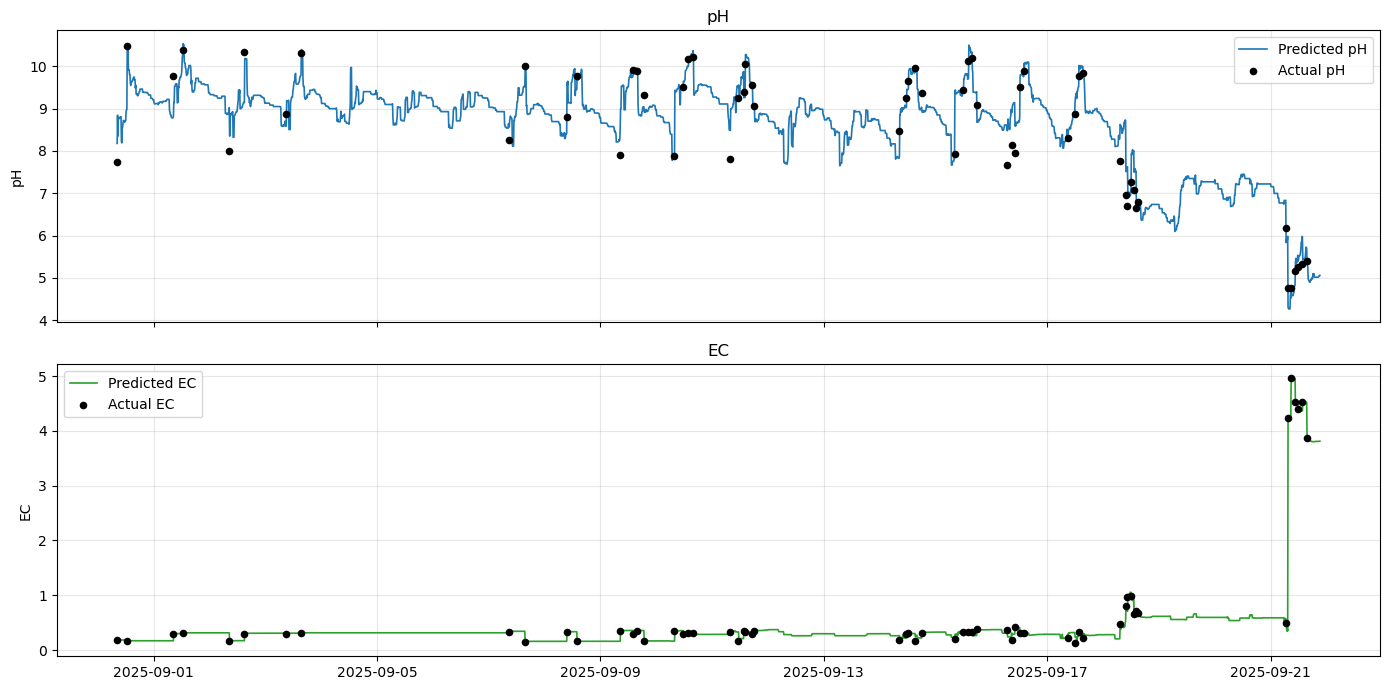

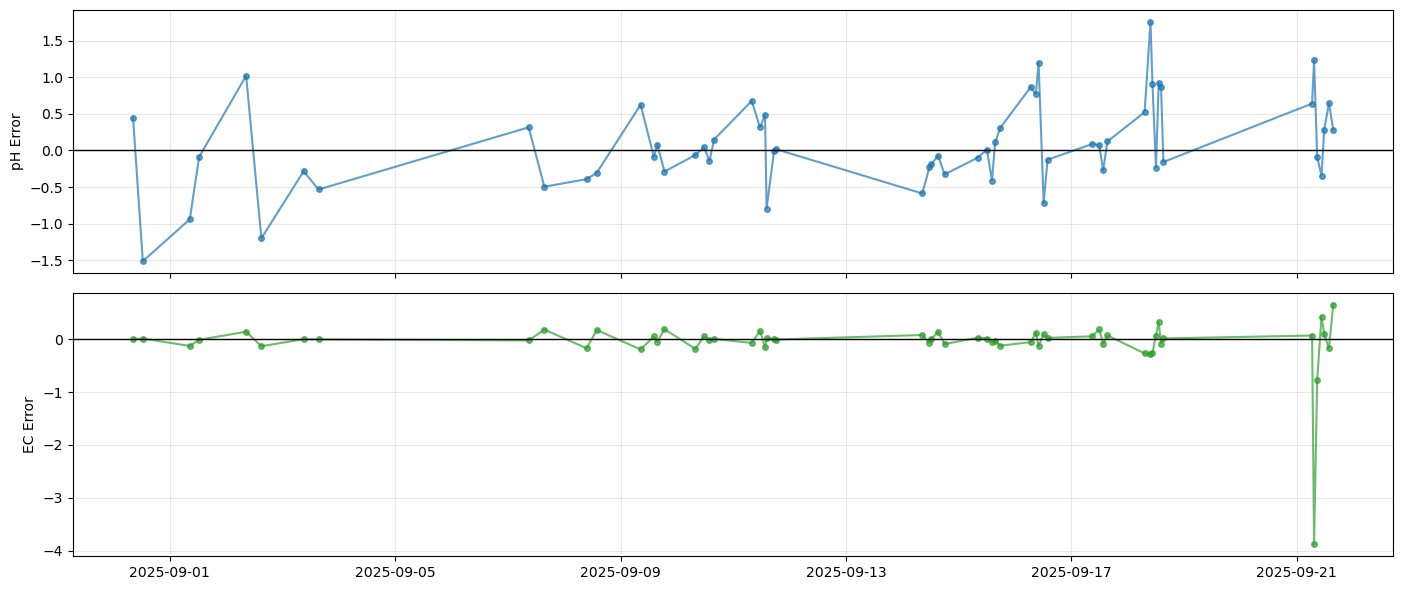

In [20]:
fig,ax=plt.subplots(2,1,figsize=(14,7),sharex=True)
ax[0].plot(res_df.index,res_df['ph_pred'],color='tab:blue',lw=1.2,label='Predicted pH')
ax[0].scatter(ev.index,ev['ph_true'],color='black',s=20,zorder=5,label='Actual pH')
ax[0].set_ylabel('pH');ax[0].legend();ax[0].grid(True,alpha=0.3);ax[0].set_title('pH')
ax[1].plot(res_df.index,res_df['ec_pred'],color='tab:green',lw=1.2,label='Predicted EC')
ax[1].scatter(ev.index,ev['ec_true'],color='black',s=20,zorder=5,label='Actual EC')
ax[1].set_ylabel('EC');ax[1].legend();ax[1].grid(True,alpha=0.3);ax[1].set_title('EC')
plt.tight_layout();plt.show()

fig,axes=plt.subplots(2,1,figsize=(14,6),sharex=True)
axes[0].plot(ev.index,ev['ph_pred']-ev['ph_true'],'o-',ms=4,alpha=0.7,color='tab:blue')
axes[0].axhline(0,lw=1,color='k');axes[0].set_ylabel('pH Error');axes[0].grid(True,alpha=0.3)
axes[1].plot(ev.index,ev['ec_pred']-ev['ec_true'],'o-',ms=4,alpha=0.7,color='tab:green')
axes[1].axhline(0,lw=1,color='k');axes[1].set_ylabel('EC Error');axes[1].grid(True,alpha=0.3)
plt.tight_layout();plt.show()

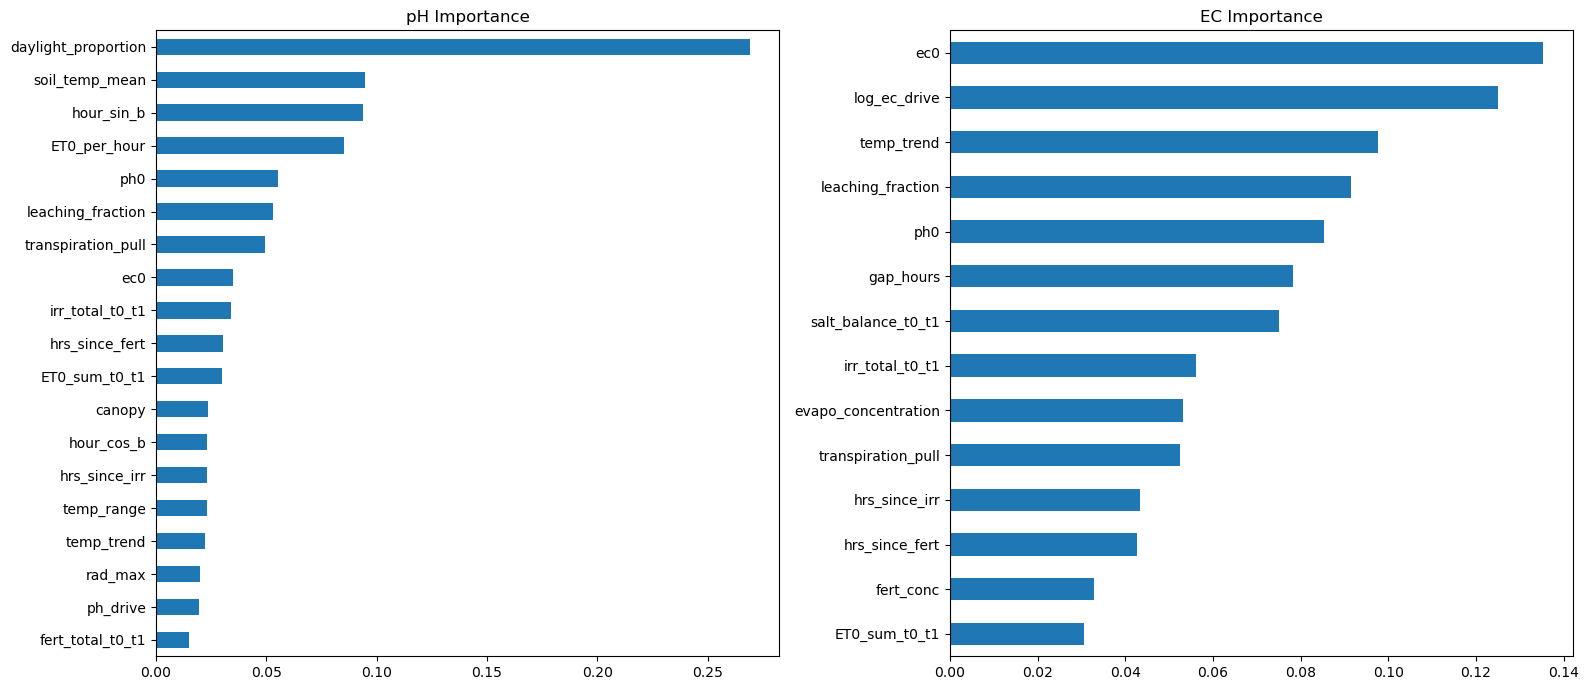

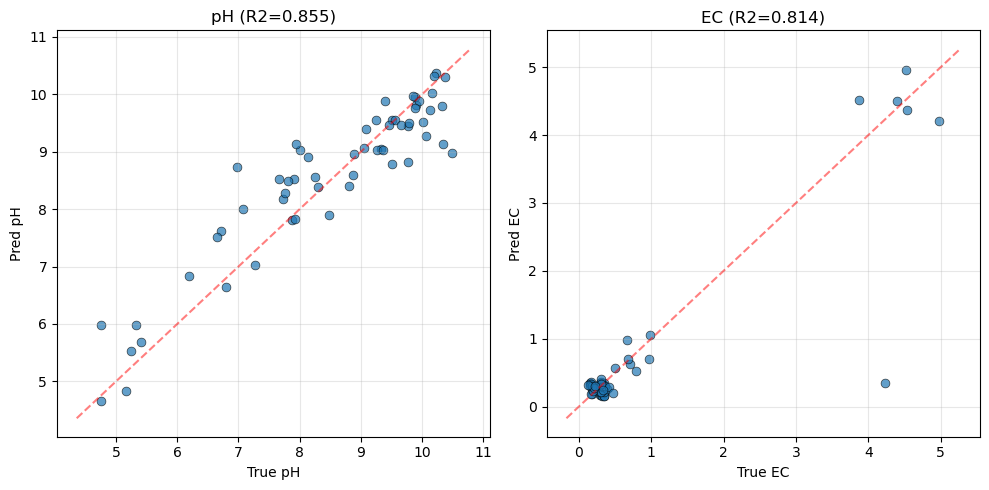

In [21]:
fig,axes=plt.subplots(1,2,figsize=(16,7))
pd.Series(ph_model.feature_importances_,index=feature_cols_ph).sort_values().plot(kind='barh',ax=axes[0],title='pH Importance')
pd.Series(ec_model.feature_importances_,index=feature_cols_ec).sort_values().plot(kind='barh',ax=axes[1],title='EC Importance')
plt.tight_layout();plt.show()

fig,axes=plt.subplots(1,2,figsize=(10,5))
for i,(n,tc,pc) in enumerate([('pH','ph_true','ph_pred'),('EC','ec_true','ec_pred')]):
    ax=axes[i];t=ev[tc].values;p=ev[pc].values
    ax.scatter(t,p,alpha=0.7,s=40,edgecolors='k',lw=0.5)
    lims=[min(t.min(),p.min())-0.3,max(t.max(),p.max())+0.3]
    ax.plot(lims,lims,'r--',alpha=0.5);ax.set_xlabel(f'True {n}');ax.set_ylabel(f'Pred {n}')
    ax.set_title(f'{n} (R2={r2_score(t,p):.3f})');ax.grid(True,alpha=0.3)
plt.tight_layout();plt.show()